# 베이스 라인

In [3]:
!pip install -q gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 96.3 MB/s eta 0:00:00:00:0100:01


In [4]:
from gensim.models import Word2Vec, FastText
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import numpy as np
from torch.utils.data import Dataset, DataLoader
from nltk.tokenize import word_tokenize
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [5]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 데이터 불러오기

In [6]:
news_data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
texts = news_data.data     # 문서 내용
labels = news_data.target  # 레이블

In [7]:
print(f"Number of documents: {len(texts)}")
print(f"Sample document: \n{texts[0]}")
print(f"Unique labels: {set(labels)}")

Number of documents: 18846
Sample document: 


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


Unique labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)

In [ ]:
# 데이터 분할
train_inputs, test_inputs, train_targets, test_targets = train_test_split(texts, labels, test_size=0.2, random_state=42)

In [ ]:
import re
nltk.download('stopwords')
stop_words = stopwords.words('english')

# 텍스트 데이터 전처리
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    stop_words = set(stopwords.words('english'))
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# 데이터에 적용 (1)
train_inputs = [clean_text(text) for text in train_inputs]
test_inputs = [clean_text(text) for text in test_inputs]

# 단어 토큰화만 진행 (2)
# train_sentences = [word_tokenize(text) for text in train_inputs]
# test_sentences = [word_tokenize(text) for text in test_inputs]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


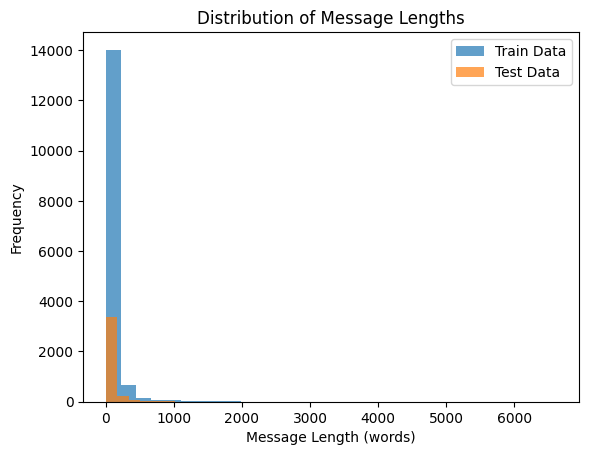

In [ ]:
# 메시지 길이 계산
train_lengths = [len(word_tokenize(msg)) for msg in train_inputs]
test_lengths = [len(word_tokenize(msg)) for msg in test_inputs]

# 히스토그램 시각화
plt.hist(train_lengths, bins=30, alpha=0.7, label='Train Data')
plt.hist(test_lengths, bins=30, alpha=0.7, label='Test Data')
plt.xlabel('Message Length (words)')
plt.ylabel('Frequency')
plt.legend()
plt.title('Distribution of Message Lengths')
plt.show()

In [ ]:
# 평균, 최대값, 중간값 계산 및 출력
print("훈련 데이터 평균 길이:", np.mean(train_lengths))
print("훈련 데이터 최대 길이:", np.max(train_lengths))
print("훈련 데이터 95분위수 길이:", np.percentile(train_lengths, 95))

훈련 데이터 평균 길이: 93.84551605200318
훈련 데이터 최대 길이: 6620
훈련 데이터 95분위수 길이: 281.25


## Word2vec

In [ ]:
# 단어 토큰화
train_sentences = [word_tokenize(text) for text in train_inputs]
test_sentences = [word_tokenize(text) for text in test_inputs]

In [ ]:
# Word2Vec 모델 학습
word2vec_model = Word2Vec(sentences=train_sentences, vector_size=128, window=5, min_count=1, sg=1)
word2vec_matrix = np.zeros((len(word2vec_model.wv) + 1, 128))
word2idx_word2vec = {word: idx + 1 for idx, word in enumerate(word2vec_model.wv.index_to_key)}

for word, idx in word2idx_word2vec.items():
    word2vec_matrix[idx] = word2vec_model.wv[word]

In [ ]:
class TextEmbeddingDataset(Dataset):
    def __init__(self, texts, labels, word2idx, max_len):
        self.texts = texts
        self.labels = labels
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = word_tokenize(self.texts[idx])
        encoded = [self.word2idx.get(word, 0) for word in tokens]  # OOV 단어는 0
        if len(encoded) < self.max_len:
            encoded += [0] * (self.max_len - len(encoded))
        else:
            encoded = encoded[:self.max_len]
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

In [ ]:
max_len = 280

# Word2Vec Dataset
train_dataset_word2vec = TextEmbeddingDataset(train_inputs, train_targets, word2idx_word2vec, max_len)
test_dataset_word2vec = TextEmbeddingDataset(test_inputs, test_targets, word2idx_word2vec, max_len)

# Word2Vec DataLoader
train_loader_word2vec = DataLoader(train_dataset_word2vec, batch_size=64, shuffle=True)
test_loader_word2vec = DataLoader(test_dataset_word2vec, batch_size=64, shuffle=False)

In [ ]:
def train(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for texts, labels in loader:
        texts, labels = texts.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(texts)  # 출력: (batch_size, 20)
        loss = criterion(outputs, labels)  # 레이블은 정수형 (0~19)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            outputs = model(texts)
            predictions = torch.argmax(outputs, dim=1)  # 가장 높은 확률의 인덱스
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return correct / total

In [ ]:
class EmbeddingLSTM(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, output_dim, num_layers=2, dropout=0.5):
        super(EmbeddingLSTM, self).__init__()
        num_embeddings, embedding_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(torch.tensor(embedding_matrix, dtype=torch.float).to(device), freeze=False)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout, bidirectional=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        output = self.fc(hidden[-1])
        return output

In [ ]:
hidden_dim = 128
output_dim = len(set(labels))

In [ ]:
model_word2vec = EmbeddingLSTM(word2vec_matrix, hidden_dim, output_dim).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_word2vec.parameters(), lr=0.005)

for epoch in range(10):
    loss = train(model_word2vec, train_loader_word2vec, loss_fn, optimizer)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

accuracy = evaluate(model_word2vec, test_loader_word2vec)
print(f"Test Accuracy (Word2Vec with LSTM): {accuracy:.4f}")

Epoch 1, Loss: 2.0305
Epoch 2, Loss: 1.1694
Epoch 3, Loss: 0.6997
Epoch 4, Loss: 0.4496
Epoch 5, Loss: 0.2950
Epoch 6, Loss: 0.2188
Epoch 7, Loss: 0.1697
Epoch 8, Loss: 0.1457
Epoch 9, Loss: 0.1318
Epoch 10, Loss: 0.1233
Test Accuracy (Word2Vec with LSTM): 0.6586


## FastText

In [ ]:
# FastText 모델 학습
fasttext_model = FastText(sentences=train_sentences, vector_size=128, window=5, min_count=1, sg=1)
fasttext_matrix = np.zeros((len(fasttext_model.wv) + 1, 128))

word2idx_fasttext = {word: idx + 1 for idx, word in enumerate(fasttext_model.wv.index_to_key)}

for word, idx in word2idx_fasttext.items():
    fasttext_matrix[idx] = fasttext_model.wv[word]

In [ ]:
# FastText Dataset
train_dataset_fasttext = TextEmbeddingDataset(train_inputs, train_targets, word2idx_fasttext, max_len)
test_dataset_fasttext = TextEmbeddingDataset(test_inputs, test_targets, word2idx_fasttext, max_len)

# FastText DataLoader
train_loader_fasttext = DataLoader(train_dataset_fasttext, batch_size=64, shuffle=True)
test_loader_fasttext = DataLoader(test_dataset_fasttext, batch_size=64, shuffle=False)

In [ ]:
model_fasttext = EmbeddingLSTM(fasttext_matrix, hidden_dim, output_dim).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_fasttext.parameters(), lr=0.005)

for epoch in range(10):
    loss = train(model_fasttext, train_loader_fasttext, loss_fn, optimizer)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

accuracy = evaluate(model_fasttext, test_loader_fasttext)
print(f"Test Accuracy (FastText with LSTM): {accuracy:.4f}")

Epoch 1, Loss: 1.9967
Epoch 2, Loss: 1.1477
Epoch 3, Loss: 0.7490
Epoch 4, Loss: 0.4946
Epoch 5, Loss: 0.3448
Epoch 6, Loss: 0.2607
Epoch 7, Loss: 0.2012
Epoch 8, Loss: 0.1671
Epoch 9, Loss: 0.1488
Epoch 10, Loss: 0.1382
Test Accuracy (FastText with LSTM): 0.6650


## GloVe

In [ ]:
import os
import urllib.request

# GloVe 다운로드 및 임베딩 로드
GLOVE_URL = "https://nlp.stanford.edu/data/glove.6B.zip"
GLOVE_ZIP = "glove.6B.zip"
GLOVE_FILE = "glove.6B.200d.txt"

if not os.path.exists(GLOVE_FILE):
    print("Downloading GloVe embeddings...")
    urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)
    import zipfile
    with zipfile.ZipFile(GLOVE_ZIP, 'r') as zip_ref:
        zip_ref.extractall()
    print("GloVe embeddings downloaded and extracted.")
else:
    print("GloVe embeddings already available.")

GloVe embeddings downloaded and extracted.


In [ ]:
embedding_dim = 200  # GloVe 임베딩 차원 설정
glove_embeddings = {}

with open(GLOVE_FILE, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coeffs = np.asarray(values[1:], dtype='float32')
        glove_embeddings[word] = coeffs

In [ ]:
len(glove_embeddings)

400000

In [ ]:
# GloVe word2idx 생성
word2idx_glove = {word: idx + 1 for idx, word in enumerate(glove_embeddings.keys())}
glove_matrix = np.zeros((len(word2idx_glove) + 1, embedding_dim))

for word, idx in word2idx_glove.items():
    embedding_vector = glove_embeddings.get(word)
    if embedding_vector is not None:
        glove_matrix[idx] = embedding_vector

In [ ]:
# GloVe Dataset
train_dataset_glove = TextEmbeddingDataset(train_inputs, train_targets, word2idx_glove, max_len)
test_dataset_glove = TextEmbeddingDataset(test_inputs, test_targets, word2idx_glove, max_len)

# GloVe DataLoader
train_loader_glove = DataLoader(train_dataset_glove, batch_size=32, shuffle=True)
test_loader_glove = DataLoader(test_dataset_glove, batch_size=32, shuffle=False)

In [ ]:
model_glove = EmbeddingLSTM(glove_matrix, hidden_dim, output_dim).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_glove.parameters(), lr=0.005)

for epoch in range(10):
    loss = train(model_glove, train_loader_glove, loss_fn, optimizer)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

accuracy = evaluate(model_glove, test_loader_glove)
print(f"Test Accuracy (GloVe with LSTM): {accuracy:.4f}")

Epoch 1, Loss: 1.7441
Epoch 2, Loss: 1.0268
Epoch 3, Loss: 0.6785
Epoch 4, Loss: 0.4661
Epoch 5, Loss: 0.3448
Epoch 6, Loss: 0.2650
Epoch 7, Loss: 0.2335
Epoch 8, Loss: 0.2107
Epoch 9, Loss: 0.1839
Epoch 10, Loss: 0.1875
Test Accuracy (GloVe with LSTM): 0.6626


# 미션 10

In [ ]:
!pip install -q gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 96.3 MB/s eta 0:00:00:00:0100:01


In [17]:
from gensim.models import Word2Vec, FastText
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import numpy as np
from torch.utils.data import Dataset, DataLoader
from nltk.tokenize import word_tokenize
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
news_data = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
texts = news_data.data     # 문서 내용
labels = news_data.target  # 레이블

## 데이터 EDA

In [ ]:
print(f"Number of documents: {len(texts)}")
print(f"Sample document: \n{texts[0]}")
print(f"Unique labels: {set(labels)}")

Number of documents: 18846
Sample document: 


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PENS RULE!!!


Unique labels: {np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)

### 클래스 불균형 확인

클래스별 데이터 개수
alt.atheism                 799
comp.graphics               973
comp.os.ms-windows.misc     985
comp.sys.ibm.pc.hardware    982
comp.sys.mac.hardware       963
comp.windows.x              988
misc.forsale                975
rec.autos                   990
rec.motorcycles             996
rec.sport.baseball          994
rec.sport.hockey            999
sci.crypt                   991
sci.electronics             984
sci.med                     990
sci.space                   987
soc.religion.christian      997
talk.politics.guns          910
talk.politics.mideast       940
talk.politics.misc          775
talk.religion.misc          628
Name: count, dtype: int64


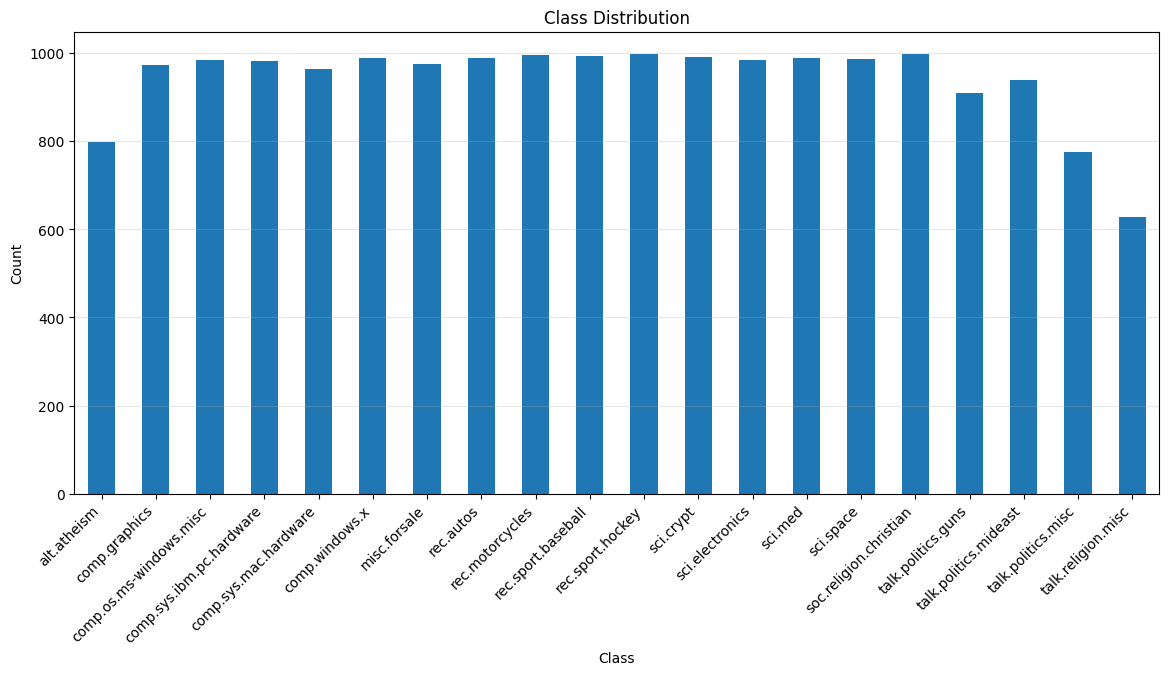

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 클래스 이름으로 변환
label_names = [news_data.target_names[label] for label in labels]

# 분포 확인
label_counts = pd.Series(label_names).value_counts().sort_index()

print("클래스별 데이터 개수")
print(label_counts)

# 그래프
plt.figure(figsize=(14, 6))
label_counts.plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.show()


대체로 클래스가 균형을 이루고 있지만 특정 몇몇 소수 클래스가 존재함

### 노이즈 확인

In [10]:
# 4. 노이즈 패턴 확인
import re
import numpy as np

url_count = sum(bool(re.search(r'http|www', text.lower())) for text in texts)
email_count = sum(bool(re.search(r'@', text)) for text in texts)
digit_count = sum(bool(re.search(r'\d', text)) for text in texts)
special_char_count = sum(bool(re.search(r'[^a-zA-Z0-9\s]', text)) for text in texts)

print(f"전체 문서 수: {len(texts)}")
print(f"URL 포함 문서 비율: {url_count / len(texts):.2%}")
print(f"이메일(@) 포함 문서 비율: {email_count / len(texts):.2%}")
print(f"숫자 포함 문서 비율: {digit_count / len(texts):.2%}")
print(f"특수문자 포함 문서 비율: {special_char_count / len(texts):.2%}")


전체 문서 수: 18846
URL 포함 문서 비율: 0.08%
이메일(@) 포함 문서 비율: 15.49%
숫자 포함 문서 비율: 57.41%
특수문자 포함 문서 비율: 97.01%


url이나 이메일은 특수 토큰으로 치환에서 vocab 수는 줄이고 패턴 정보는 유지하는 식으로 진행하려 함

### 이상치 확인

In [11]:
# 5. 이상치 샘플 직접 보기 (가장 짧은 문서 / 가장 긴 문서)
text_lengths = [len(text.split()) for text in texts]

short_idx = sorted(range(len(text_lengths)), key=lambda i: text_lengths[i])[:5]
long_idx = sorted(range(len(text_lengths)), key=lambda i: text_lengths[i], reverse=True)[:5]

print("가장 짧은 문서 5개")
for i in short_idx:
    print(f"\n[인덱스 {i}] 길이: {text_lengths[i]}, label: {news_data.target_names[labels[i]]}")
    print(texts[i][:1000])
    print("-" * 80)

print("\n가장 긴 문서 5개")
for i in long_idx:
    print(f"\n[인덱스 {i}] 길이: {text_lengths[i]}, label: {news_data.target_names[labels[i]]}")
    print(texts[i][:1000])
    print("-" * 80)


가장 짧은 문서 5개

[인덱스 91] 길이: 0, label: talk.religion.misc

--------------------------------------------------------------------------------

[인덱스 104] 길이: 0, label: talk.religion.misc

--------------------------------------------------------------------------------

[인덱스 127] 길이: 0, label: rec.sport.hockey

--------------------------------------------------------------------------------

[인덱스 135] 길이: 0, label: talk.politics.mideast

--------------------------------------------------------------------------------

[인덱스 161] 길이: 0, label: comp.sys.ibm.pc.hardware

--------------------------------------------------------------------------------

가장 긴 문서 5개

[인덱스 17014] 길이: 11765, label: sci.electronics
Since electrical wiring questions do turn up from time to time on
sci.electronics (and the answers aren't always apparent, even to those skilled
in electronics), I am hijacking the following FAQ and posting a copy here. 
I've asked the writers to cross-post to sci.electronics in the future. 


짧은 문서는 빈 문서가 출력돼서 전처리 후 다시 확인해봐야하고 킨 문서의 경우 필요없는 장식이 많아서 전처리가 필요함

### 중복 결측 확인

In [12]:
# 6. 중복 / 결측 확인
import pandas as pd

df_text = pd.DataFrame({
    "text": texts,
    "label": labels
})

empty_count = sum((text is None) or (str(text).strip() == "") for text in texts)
duplicate_count = df_text.duplicated(subset=["text"]).sum()

print(f"빈 문서 수: {empty_count}")
print(f"중복 문서 수(텍스트 기준): {duplicate_count}")


빈 문서 수: 515
중복 문서 수(텍스트 기준): 559


중복 문서와 빈 문서 수가 많아서 전처리 필요함.

## 전처리

In [18]:
import re
nltk.download('stopwords')
stop_words = stopwords.words('english')

# 1. 소문자화
def to_lower(text):
    return text.lower()

# 2. URL / 이메일 / 숫자 치환
def replace_special_patterns(text):
    text = re.sub(r'http\S+|www\S+', ' URLTOKEN ', text)
    text = re.sub(r'\S+@\S+', ' EMAILTOKEN ', text)
    text = re.sub(r'\b\d+\b', ' NUMTOKEN ', text)
    return text

# 3. 장식 줄 제거
def remove_meta_and_ascii_lines(text):
    cleaned_lines = []

    for line in text.split('\n'):
        line = line.strip()

        # 빈 줄은 일단 넘김
        if not line:
            continue

        # 메타데이터 줄 제거
        if re.match(r'^(from|subject|organization|reply-to|date|message-id|archive-name|last-modified|newsgroups|lines|summary|expires|followup-to)\s*:', line.lower()):
            continue

        # 장식용 구분선 제거
        if re.fullmatch(r'[-=+_*~|]{5,}', line):
            continue

        # 박스 테두리 문자 제거 (내용은 남김)
        line = re.sub(r'^\|+', '', line)
        line = re.sub(r'\|+$', '', line)
        line = re.sub(r'^\++', '', line)
        line = re.sub(r'\++$', '', line)

        line = line.strip()

        if line:
            cleaned_lines.append(line)

    return ' '.join(cleaned_lines)

# 4. 불필요한 특수문자 정리 + 공백 정리
def clean_special_characters(text):
    # 토큰으로 남길 단어와 공백만 유지
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # 공백 여러 개를 하나로
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# 5. 토큰화
def tokenize_text(text):
    return word_tokenize(text)

# 6. 불용어 제거
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [19]:
# 전체 전처리 함수
def clean_text(text, remove_stopword=True):
    text = to_lower(text)
    text = replace_special_patterns(text)
    text = remove_meta_and_ascii_lines(text)
    text = clean_special_characters(text)

    tokens = tokenize_text(text)

    if remove_stopword:
        tokens = remove_stopwords(tokens)

    return ' '.join(tokens)


In [ ]:
train_inputs, test_inputs, train_targets, test_targets = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

raw_train_inputs = train_inputs.copy()
raw_test_inputs = test_inputs.copy()

train_inputs = [clean_text(text) for text in train_inputs]
test_inputs = [clean_text(text) for text in test_inputs]


## 전처리 후 데이터 확인

In [ ]:
### 

train 평균 길이: 109.6677500663306
train 중앙값 길이: 45.0
train 최대 길이: 19809
train 95분위수 길이: 305.0
train 99분위수 길이: 1074.0


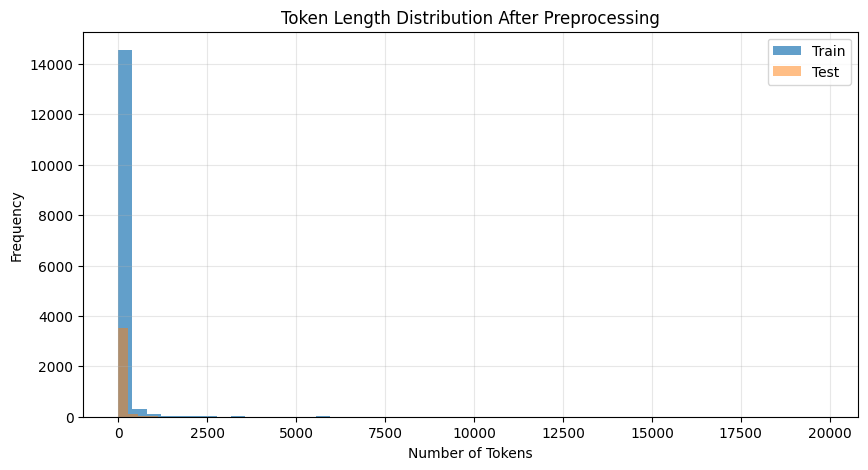

In [21]:
# 1. 전처리 후 길이 분포
import numpy as np
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize

train_lengths = [len(word_tokenize(text)) for text in train_inputs]
test_lengths = [len(word_tokenize(text)) for text in test_inputs]

print("train 평균 길이:", np.mean(train_lengths))
print("train 중앙값 길이:", np.median(train_lengths))
print("train 최대 길이:", np.max(train_lengths))
print("train 95분위수 길이:", np.percentile(train_lengths, 95))
print("train 99분위수 길이:", np.percentile(train_lengths, 99))

plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=50, alpha=0.7, label="Train")
plt.hist(test_lengths, bins=50, alpha=0.5, label="Test")
plt.title("Token Length Distribution After Preprocessing")
plt.xlabel("Number of Tokens")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [22]:
# 2. 빈 문서 / 너무 짧은 문서 확인
empty_docs = [i for i, text in enumerate(train_inputs) if len(text.strip()) == 0]
short_docs = [i for i, text in enumerate(train_inputs) if 0 < len(text.split()) <= 3]

print(f"빈 문서 개수: {len(empty_docs)}")
print(f"너무 짧은 문서 개수(1~3토큰): {len(short_docs)}")

print("\n빈 문서 예시 인덱스 5개:", empty_docs[:5])

print("\n너무 짧은 문서 예시 5개")
for i in short_docs[:5]:
    print(f"[인덱스 {i}] 길이: {len(train_inputs[i].split())}")
    print(train_inputs[i])
    print("-" * 60)


빈 문서 개수: 435
너무 짧은 문서 개수(1~3토큰): 198

빈 문서 예시 인덱스 5개: [21, 69, 87, 90, 137]

너무 짧은 문서 예시 5개
[인덱스 64] 길이: 3
cam chain mike
------------------------------------------------------------
[인덱스 105] 길이: 3
sender distribution keywords
------------------------------------------------------------
[인덱스 129] 길이: 2
bill mcd
------------------------------------------------------------
[인덱스 192] 길이: 3
assume sarcastic remark
------------------------------------------------------------
[인덱스 363] 길이: 2
sub says
------------------------------------------------------------


In [ ]:
# 3. 전처리 전후 비교
for i in range(5):
    print(f"[샘플 {i+1}]")
    print("전처리 전:")
    print(raw_train_inputs[i][:700])
    print("\n전처리 후:")
    print(train_inputs[i][:700])
    print("=" * 80)


[샘플 1]
전처리 전:


I am sure some bashers of Pens fans are pretty confused about the lack
of any kind of posts about the recent Pens massacre of the Devils. Actually,
I am  bit puzzled too and a bit relieved. However, I am going to put an end
to non-PIttsburghers' relief with a bit of praise for the Pens. Man, they
are killing those Devils worse than I thought. Jagr just showed you why
he is much better than his regular season stats. He is also a lot
fo fun to watch in the playoffs. Bowman should let JAgr have a lot of
fun in the next couple of games since the Pens are going to beat the pulp out of Jersey anyway. I was very disappointed not to see the Islanders lose the final
regular season game.          PE

전처리 후:
gotten posts group last couple days recently added feed list group near death seen mailing list side getting right amount traffic patrick l mahan tgv window washer EMAILTOKEN waking person unnecessarily considered lazarus long capital crime first offense notebooks lazarus long

In [24]:
# 4. 상위 빈출 단어 확인
from collections import Counter

all_tokens = []
for text in train_inputs:
    all_tokens.extend(word_tokenize(text))

token_counts = Counter(all_tokens)

print("상위 빈출 단어 30개")
print(token_counts.most_common(30))


상위 빈출 단어 30개
[('NUMTOKEN', 130730), ('ax', 32669), ('EMAILTOKEN', 10457), ('x', 9638), ('one', 8337), ('would', 8045), ('like', 5266), ('people', 5105), ('q', 5023), ('get', 4658), ('know', 4594), ('f', 4556), ('g', 4496), ('b', 4461), ('also', 4363), ('v', 4189), ('w', 4134), ('p', 4097), ('c', 3995), ('time', 3975), ('think', 3962), ('use', 3960), ('e', 3804), ('r', 3728), ('could', 3358), ('new', 3300), ('well', 3261), ('u', 3251), ('may', 3141), ('good', 3084)]


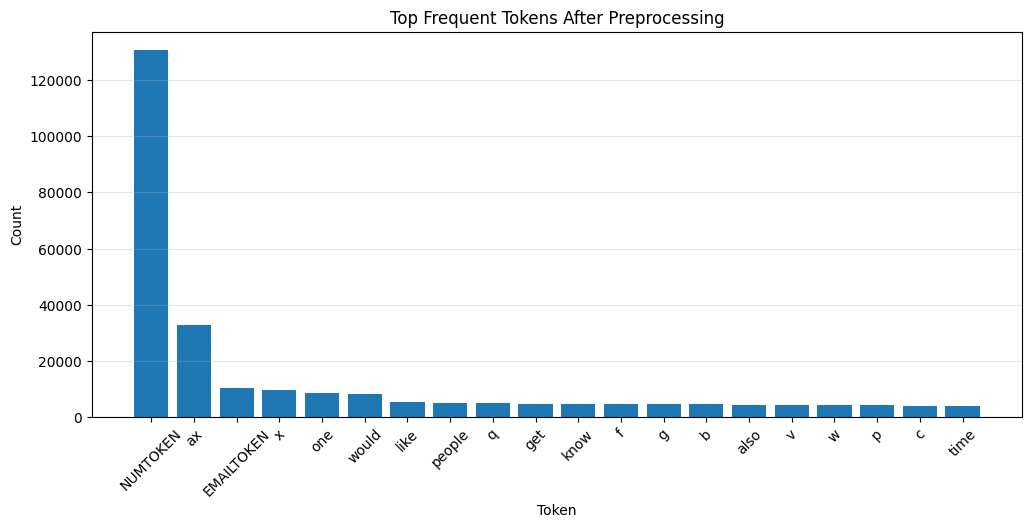

In [25]:
# 상위 20개 단어 시각화
top_k = 20
top_words = token_counts.most_common(top_k)

words = [w for w, c in top_words]
counts = [c for w, c in top_words]

plt.figure(figsize=(12, 5))
plt.bar(words, counts)
plt.title("Top Frequent Tokens After Preprocessing")
plt.xlabel("Token")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()


일단 단어가 문제가 있어보이고 짧은 문장 지우기도 해야되고 긴문자옫 어떻게 할지 고민해야함 내일은 여기부터 해보자